# DQN 三大创新 — 实验可视化

生成文章配图，对应 DQN 三个核心创新：

1. **神经网络逼近 Q 值** — 动机：维度灾难
2. **经验回放** — 有 / 无对比训练曲线
3. **目标网络** — 有 / 无对比训练稳定性

环境：CartPole-v1 | 预计运行时间：5–10 分钟

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import deque
import random

# ── Academic style ──────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#CCCCCC',
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#DDDDDD',
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    2.0,
    'savefig.bbox':       'tight',
})

# Color palette
C_BLUE   = '#2166AC'
C_RED    = '#D6604D'
C_PURPLE = '#762A83'
C_GREEN  = '#4DAC26'
C_GRAY   = '#888888'

# ── gymnasium / gym compatibility ───────────────────────────────
try:
    import gymnasium as gym
    def make_env(name):        return gym.make(name)
    def reset_env(env, seed=None):
        obs, _ = env.reset(seed=seed); return obs
    def step_env(env, action):
        obs, r, ter, tru, _ = env.step(action); return obs, r, ter or tru
    print('Using gymnasium')
except ImportError:
    import gym
    def make_env(name):        return gym.make(name)
    def reset_env(env, seed=None):
        if seed is not None: env.seed(seed)
        return env.reset()
    def step_env(env, action):
        obs, r, done, _ = env.step(action); return obs, r, done
    print('Using gym')

print('Setup complete.')

---
## Figure 1 — Curse of Dimensionality

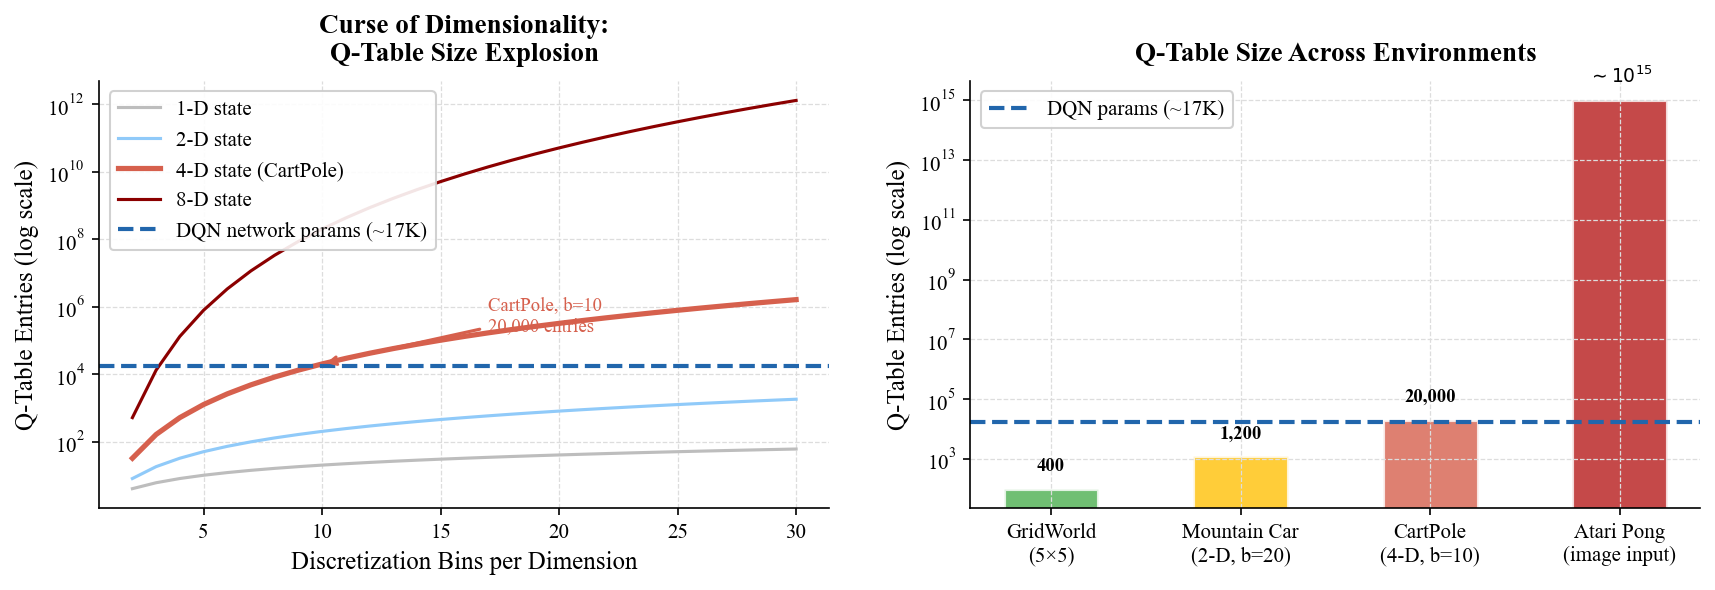

Saved: fig1_qtable_motivation.pdf


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: Q-table size vs. bins, different state dims ───────────
ax = axes[0]
bins       = np.arange(2, 31)
n_actions  = 2
dims       = [1, 2, 4, 8]
dim_colors = ['#BDBDBD', '#90CAF9', C_RED, '#8B0000']
dim_labels = ['1-D state', '2-D state', '4-D state (CartPole)', '8-D state']

for d, color, label in zip(dims, dim_colors, dim_labels):
    sizes = (bins ** d) * n_actions
    lw = 2.5 if d == 4 else 1.5
    ax.semilogy(bins, sizes, color=color, linewidth=lw, label=label)

# Neural network parameter count as reference (4 -> 128 -> 128 -> 2)
nn_params = (4*128 + 128) + (128*128 + 128) + (128*2 + 2)  # 17,282
ax.axhline(y=nn_params, color=C_BLUE, linestyle='--', linewidth=2.0,
           label=f'DQN network params (~{nn_params//1000}K)')

b10_size = 10**4 * 2  # CartPole, b=10
ax.annotate(
    f'CartPole, b=10\n{b10_size:,} entries',
    xy=(10, b10_size), xytext=(17, b10_size * 10),
    arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.5),
    fontsize=9, color=C_RED
)

ax.set_xlabel('Discretization Bins per Dimension')
ax.set_ylabel('Q-Table Entries (log scale)')
ax.set_title('Curse of Dimensionality:\nQ-Table Size Explosion')
ax.legend(loc='upper left')
ax.grid(True, which='both')

# ── Right: Q-table size across environments ──────────────────────
ax2 = axes[1]
env_names  = ['GridWorld\n(5×5)', 'Mountain Car\n(2-D, b=20)',
              'CartPole\n(4-D, b=10)', 'Atari Pong\n(image input)']
env_sizes  = [5*5*4, 20**2*3, 10**4*2, int(1e15)]
env_colors = ['#4CAF50', '#FFC107', C_RED, '#B71C1C']

bars = ax2.bar(env_names, env_sizes, color=env_colors,
               alpha=0.80, edgecolor='white', linewidth=1.5, width=0.5)
ax2.set_yscale('log')
ax2.axhline(y=nn_params, color=C_BLUE, linestyle='--', linewidth=2.0,
            label=f'DQN params (~{nn_params//1000}K)')

bar_labels = ['400', '1,200', '20,000', r'$\sim 10^{15}$']
for bar, lbl in zip(bars, bar_labels):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 3,
             lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_ylabel('Q-Table Entries (log scale)')
ax2.set_title('Q-Table Size Across Environments')
ax2.legend()
ax2.grid(True, which='both', axis='y')

plt.tight_layout(pad=2.5)
plt.savefig('fig1_qtable_motivation.pdf')
plt.show()
print('Saved: fig1_qtable_motivation.pdf')

---
## DQN 实现（图 2 & 3 共用）

In [11]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),   nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int64),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

In [12]:
def train_dqn(
    n_episodes=400, seed=42,
    use_replay=True, use_target=True,
    lr=3e-4, gamma=0.99,
    buffer_size=10000, batch_size=64, min_buffer=500,
    target_update_freq=100,
    eps_start=1.0, eps_end=0.01, eps_decay=0.995,
    hidden=128
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env        = make_env('CartPole-v1')
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net     = QNetwork(state_dim, action_dim, hidden)
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    if use_target:
        target_net = QNetwork(state_dim, action_dim, hidden)
        target_net.load_state_dict(q_net.state_dict())
        target_net.eval()
    else:
        target_net = q_net  # same object -> target moves every gradient step

    # No replay: degenerate to single-step online update
    buf_size = buffer_size if use_replay else 1
    bsz      = batch_size  if use_replay else 1
    min_buf  = min_buffer  if use_replay else 1
    buffer   = ReplayBuffer(buf_size)

    epsilon         = eps_start
    step_count      = 0
    episode_rewards = []

    for ep in range(n_episodes):
        state        = reset_env(env, seed=seed + ep)
        total_reward = 0.0
        done         = False

        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s      = torch.FloatTensor(state).unsqueeze(0)
                    action = q_net(s).argmax(dim=1).item()

            next_state, reward, done = step_env(env, action)
            buffer.push(state, action, reward, next_state, float(done))
            state        = next_state
            total_reward += reward
            step_count   += 1

            if len(buffer) >= min_buf:
                s_b, a_b, r_b, ns_b, d_b = buffer.sample(bsz)
                s_t  = torch.FloatTensor(s_b)
                a_t  = torch.LongTensor(a_b).unsqueeze(1)
                r_t  = torch.FloatTensor(r_b)
                ns_t = torch.FloatTensor(ns_b)
                d_t  = torch.FloatTensor(d_b)

                curr_q = q_net(s_t).gather(1, a_t).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(ns_t).max(dim=1)[0]
                    tgt_q  = r_t + gamma * next_q * (1 - d_t)

                loss = nn.MSELoss()(curr_q, tgt_q)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
                optimizer.step()

                if use_target and step_count % target_update_freq == 0:
                    target_net.load_state_dict(q_net.state_dict())

        epsilon = max(eps_end, epsilon * eps_decay)
        episode_rewards.append(total_reward)

    env.close()
    return np.array(episode_rewards)


def run_seeds(n_seeds=3, **kwargs):
    all_rewards = []
    for i in range(n_seeds):
        seed = i * 100 + 42
        print(f'  seed={seed} ...', end='', flush=True)
        rewards = train_dqn(seed=seed, **kwargs)
        print(f'  last-50 avg: {np.mean(rewards[-50:]):.1f}')
        all_rewards.append(rewards)
    return np.array(all_rewards)

In [20]:
def smooth(arr, window=30):
    return np.convolve(arr, np.ones(window) / window, mode='valid')


def plot_comparison(res_a, res_b, label_a, label_b, title, filename,
                    color_a=C_BLUE, color_b=C_RED, window=30):
    fig, ax = plt.subplots(figsize=(8, 4.5))

    for res, label, color in [(res_a, label_a, color_a), (res_b, label_b, color_b)]:
        smoothed = np.array([smooth(r, window) for r in res])
        mean = smoothed.mean(axis=0)
        std  = smoothed.std(axis=0)
        x    = np.arange(window - 1, res.shape[1])
        ax.plot(x, mean, label=label, color=color, linewidth=2.5)
        ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)

    ax.axhline(y=195, color=C_GREEN, linestyle=':', linewidth=1.8,
               alpha=0.8, label='Solved threshold (195)')

    ax.set_xlabel('Episode')
    ax.set_ylabel('Episode Return')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 230)
    ax.text(0.98, 0.04,
            f'n = {res_a.shape[0]} seeds, smoothing window = {window}',
            transform=ax.transAxes, ha='right', fontsize=8.5, color=C_GRAY,
            style='italic')

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f'Saved: {filename}')
    return fig

---
## Figure 2 — Experience Replay

In [14]:
print('=== Experiment 1: Experience Replay ===')
print('\n[A] With replay buffer (capacity=10000, batch=64)')
res_with_replay = run_seeds(n_seeds=3, use_replay=True, use_target=True, n_episodes=400)

print('\n[B] Without replay buffer (online single-step update)')
res_no_replay = run_seeds(n_seeds=3, use_replay=False, use_target=True, n_episodes=400)

=== Experiment 1: Experience Replay ===

[A] With replay buffer (capacity=10000, batch=64)
  seed=42 ...  last-50 avg: 216.4
  seed=142 ...  last-50 avg: 173.6
  seed=242 ...  last-50 avg: 349.0

[B] Without replay buffer (online single-step update)
  seed=42 ...  last-50 avg: 10.0
  seed=142 ...  last-50 avg: 10.4
  seed=242 ...  last-50 avg: 10.5


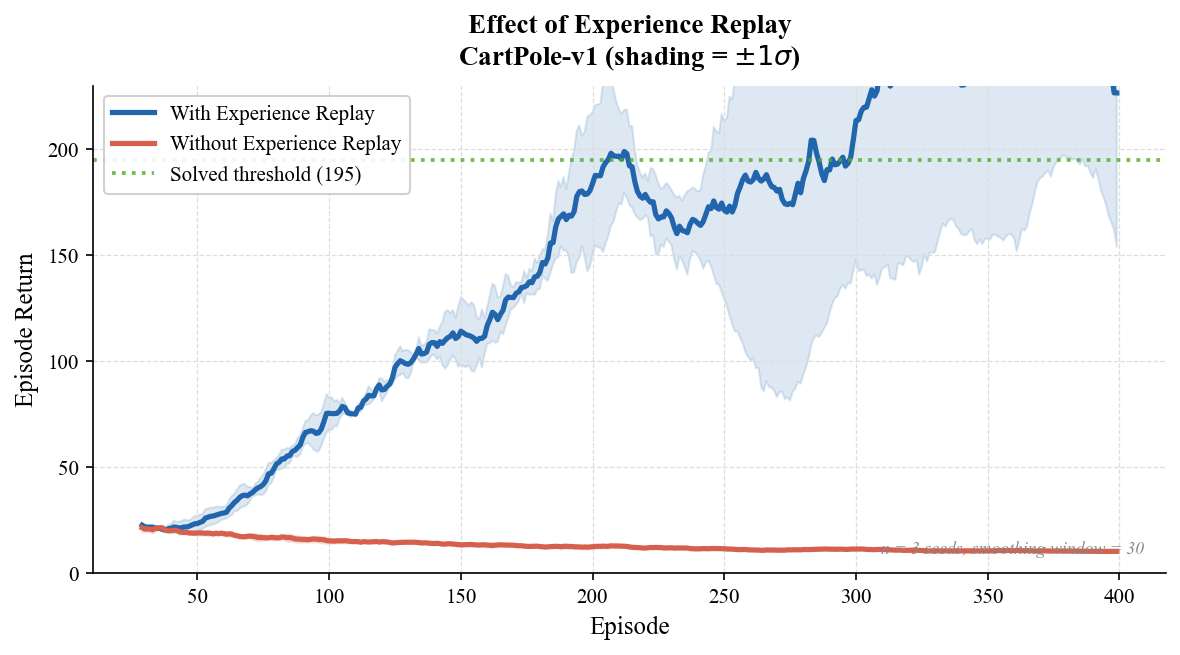

Saved: fig2_replay_comparison.pdf


In [21]:
fig2 = plot_comparison(
    res_with_replay, res_no_replay,
    label_a='With Experience Replay',
    label_b='Without Experience Replay',
    title='Effect of Experience Replay\nCartPole-v1 (shading = $\\pm 1\\sigma$)',
    filename='fig2_replay_comparison.pdf'
)

---
## Figure 3 — Target Network

In [16]:
print('=== Experiment 2: Target Network ===')
print('\n[A] With target network (sync every 100 steps)')
res_with_target = run_seeds(n_seeds=3, use_replay=True, use_target=True, n_episodes=400)

print('\n[B] Without target network (q_net used as its own target)')
res_no_target = run_seeds(n_seeds=3, use_replay=True, use_target=False, n_episodes=400)

=== Experiment 2: Target Network ===

[A] With target network (sync every 100 steps)
  seed=42 ...  last-50 avg: 106.7
  seed=142 ...  last-50 avg: 336.6
  seed=242 ...  last-50 avg: 276.5

[B] Without target network (q_net used as its own target)
  seed=42 ...  last-50 avg: 11.0
  seed=142 ...  last-50 avg: 32.7
  seed=242 ...  last-50 avg: 132.3


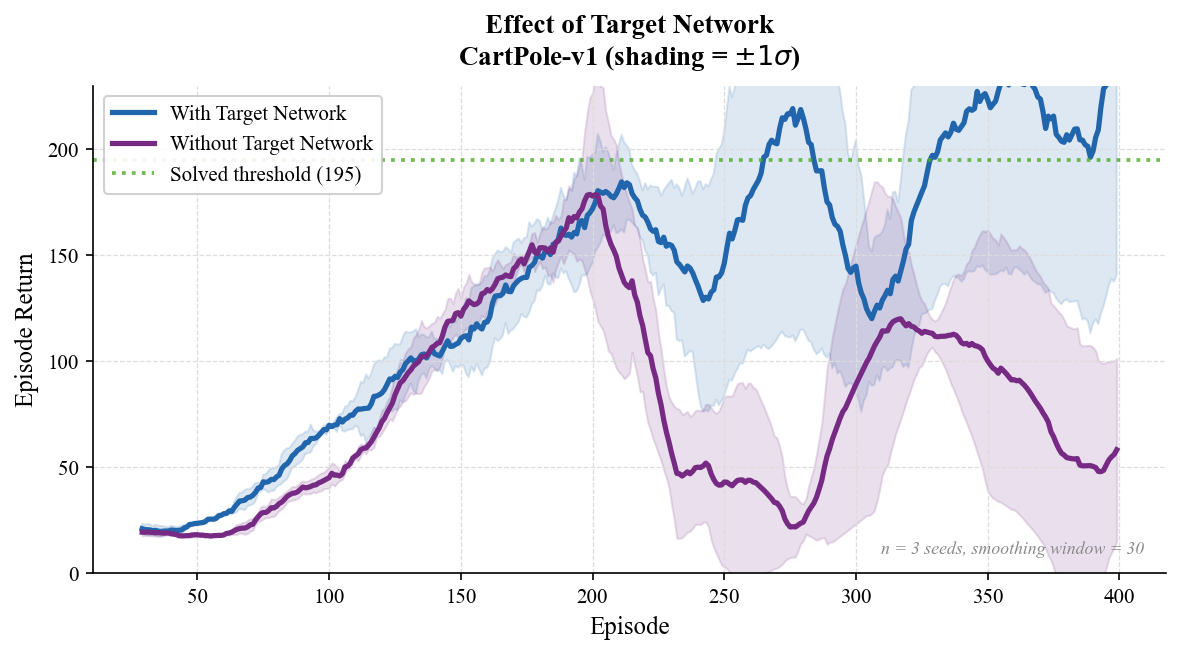

Saved: fig3_target_comparison.pdf


In [22]:
fig3 = plot_comparison(
    res_with_target, res_no_target,
    label_a='With Target Network',
    label_b='Without Target Network',
    title='Effect of Target Network\nCartPole-v1 (shading = $\\pm 1\\sigma$)',
    filename='fig3_target_comparison.pdf',
    color_a=C_BLUE,
    color_b=C_PURPLE
)

In [ ]:
print('All figures saved:')
print('  fig1_qtable_motivation.pdf')
print('  fig2_replay_comparison.pdf')
print('  fig3_target_comparison.pdf')